In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/SAE_Project"

In [ ]:
!ls "/content/drive/MyDrive"

'Colab Notebooks'   SAE_Project


Module 1: Prompts

In [ ]:
import json
import random

coding_prompts = [

    "Write merge sort in Python",
    "Write quick sort in Python",
    "Write bubble sort in Python",
    "Write insertion sort",
    "Write binary search",
    "Write linear search",
    "Explain recursion",
    "Explain dynamic programming",
    "Explain object oriented programming",
    "Explain linked lists",
    "Explain stacks",
    "Explain queues",
    "Explain trees",
    "Explain graphs",
    "Debug this Python code",
    "Find the bug in this program",
    "Write a DFS algorithm",
    "Write a BFS algorithm",
    "Explain hash tables",
    "Explain time complexity"

]

math_prompts = [

    "Solve x² + 5x + 6 = 0",
    "Find derivative of x³ + 2x",
    "Integrate x²",
    "Explain calculus",
    "Explain linear algebra",
    "What is matrix multiplication",
    "Solve a system of equations",
    "Explain probability",
    "Explain Bayes theorem",
    "Find determinant of a matrix",
    "Explain vectors",
    "Explain eigenvalues",
    "What is a limit in mathematics",
    "Explain logarithms",
    "Solve a quadratic equation",
    "Explain trigonometry",
    "Find area of a circle",
    "Explain statistics",
    "What is standard deviation",
    "Explain permutations and combinations"

]

science_prompts = [

    "Explain gravity",
    "Explain DNA",
    "What is photosynthesis",
    "Explain black holes",
    "Explain quantum physics",
    "Explain atoms",
    "Explain molecules",
    "What is evolution",
    "Explain the solar system",
    "Explain electricity",
    "Explain magnetism",
    "Explain relativity",
    "Explain the water cycle",
    "Explain climate change",
    "Explain renewable energy",
    "What is a cell",
    "Explain the nervous system",
    "Explain chemical reactions",
    "Explain ecosystems",
    "Explain the periodic table"

]

history_prompts = [

    "Who was Napoleon",
    "Explain World War 2",
    "History of India",
    "Explain the French Revolution",
    "Explain the Industrial Revolution",
    "Who was Mahatma Gandhi",
    "History of Ancient Egypt",
    "History of Rome",
    "History of China",
    "History of the Mughal Empire",
    "Explain World War 1",
    "Explain the Cold War",
    "Who was Julius Caesar",
    "Who was Alexander the Great",
    "History of the Renaissance",
    "History of Democracy",
    "History of the Internet",
    "History of Space Exploration",
    "History of the United Nations",
    "History of South India"

]

reasoning_prompts = [

    "Why is the sky blue",
    "Explain causality",
    "What is logic",
    "Explain critical thinking",
    "What is deduction",
    "What is induction",
    "Explain decision making",
    "Explain problem solving",
    "How do humans reason",
    "Explain cognitive bias",
    "What is analytical thinking",
    "Explain logical fallacies",
    "Explain abductive reasoning",
    "How does evidence support a claim",
    "Explain argument analysis",
    "What is rational thinking",
    "Explain cause and effect",
    "How do we evaluate evidence",
    "Explain scientific reasoning",
    "Explain hypothesis testing"

]

all_prompts = []

for _ in range(400):
    all_prompts.append(random.choice(coding_prompts))

for _ in range(400):
    all_prompts.append(random.choice(math_prompts))

for _ in range(400):
    all_prompts.append(random.choice(science_prompts))

for _ in range(400):
    all_prompts.append(random.choice(history_prompts))

for _ in range(400):
    all_prompts.append(random.choice(reasoning_prompts))

random.shuffle(all_prompts)

with open(
    "prompts.json",
    "w"
) as f:

    json.dump(
        all_prompts,
        f,
        indent=4
    )

print(
    "Total Prompts:",
    len(all_prompts)
)

Total Prompts: 2000


In [ ]:
import shutil

shutil.copy(
    "prompts.json",
    "/content/drive/MyDrive/SAE_Project/prompts.json"
)

print("Saved prompts.json")

Saved prompts.json


Module 2:

In [ ]:
import torch
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
import json
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

name='TinyLlama/TinyLlama-1.1B-Chat-v1.0'

tokenizer=AutoTokenizer.from_pretrained(name)
print('Tokenizer uploaed')

model=AutoModelForCausalLM.from_pretrained(name,output_hidden_states=True,torch_dtype=torch.float16 if device=='cuda' else torch.float32)
model.to(device)
model.eval()
print('model uploaded succesfuuly')

with open ('prompts.json','r') as f:
  prompts=json.load(f)

all_activations=[]
for idx, prompt in enumerate(prompts):

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(prompts)} prompts")

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
      outputs=model(**inputs,output_hidden_states=True)

    hidden=outputs.hidden_states[12]
    activation=hidden[:,-1,:]
    all_activations.append(activation.cpu().float())

all_activations=torch.cat(all_activations,dim=0)
torch.save(all_activations,'activations.pt')

print('saved activations')
print('shape',all_activations.shape)
print('dtype',all_activations.dtype)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

model uploaded succesfuuly
Processed 0/2000 prompts
Processed 10/2000 prompts
Processed 20/2000 prompts
Processed 30/2000 prompts
Processed 40/2000 prompts
Processed 50/2000 prompts
Processed 60/2000 prompts
Processed 70/2000 prompts
Processed 80/2000 prompts
Processed 90/2000 prompts
Processed 100/2000 prompts
Processed 110/2000 prompts
Processed 120/2000 prompts
Processed 130/2000 prompts
Processed 140/2000 prompts
Processed 150/2000 prompts
Processed 160/2000 prompts
Processed 170/2000 prompts
Processed 180/2000 prompts
Processed 190/2000 prompts
Processed 200/2000 prompts
Processed 210/2000 prompts
Processed 220/2000 prompts
Processed 230/2000 prompts
Processed 240/2000 prompts
Processed 250/2000 prompts
Processed 260/2000 prompts
Processed 270/2000 prompts
Processed 280/2000 prompts
Processed 290/2000 prompts
Processed 300/2000 prompts
Processed 310/2000 prompts
Processed 320/2000 prompts
Processed 330/2000 prompts
Processed 340/2000 prompts
Processed 350/2000 prompts
Processed 36

In [ ]:
import shutil

shutil.copy(
    "activations.pt",
    "/content/drive/MyDrive/SAE_Project/activations.pt"
)

print("Saved activations.pt")

Saved activations.pt


Module :3 Creating SparseAotoencoder Model

In [ ]:
import torch

activations = torch.load("activations.pt")

print("Shape:", activations.shape)
print("Dtype:", activations.dtype)

Shape: torch.Size([2000, 2048])
Dtype: torch.float32


In [ ]:
%%writefile sae_model.py

import torch
import torch.nn as nn

class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim, hidden_dim):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()

    def encode(self,x):
      return self.relu(self.encoder(x))

    def decode(self,z):
      return self.decoder(z)

    def forward(self, x):
        z = self.relu(self.encoder(x))
        recon = self.decoder(z)
        return recon, z

Writing sae_model.py


Module:4 Training Sae Model

In [ ]:
import torch
import torch.nn as nn
from sae_model import SparseAutoencoder

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

sparcity_lamba=1e-3

data=torch.load('activations.pt').float().to(device)

input_dim=data.shape[1]
hidden_dim=input_dim*4

model=SparseAutoencoder(input_dim,hidden_dim).to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=1e-3) #all weights n bias
mse=nn.MSELoss()
loss_history = []
recon_history = []
sparsity_history = []
for epoch in range(300):
  recon,z=model(data) #reconstructed activation n latent features
  recon_loss=mse(recon,data) #reconstructed activation n actual activation comparison
  sparsity_loss=torch.mean(torch.abs(z)) #checks whivh feature is active
  loss=(recon_loss+sparcity_lamba*sparsity_loss)
  loss_history.append(loss.item())
  recon_history.append(recon_loss.item())
  sparsity_history.append(sparsity_loss.item())
  optimizer.zero_grad() # cleans olf gradients
  loss.backward() #computes gradients
  optimizer.step()  #update weights

  if epoch%10==0:
    print(f"Epoch {epoch} ,loss {loss.item()}")


torch.save(model.state_dict(),'sae.pt') #sae contion encoder n decoder weights and bias
print('trainng complete')

print('final reconstruction loss:',recon_loss.item())
print("final sparsity loss:",sparsity_loss.item())
print('saved sae.pt')

Using Device: cuda
Epoch 0 ,loss 0.01710074581205845
Epoch 10 ,loss 0.012276765890419483
Epoch 20 ,loss 0.005252840928733349
Epoch 30 ,loss 0.002852869685739279
Epoch 40 ,loss 0.0015836255624890327
Epoch 50 ,loss 0.0008453829796053469
Epoch 60 ,loss 0.00043274866766296327
Epoch 70 ,loss 0.0002322395594092086
Epoch 80 ,loss 0.00012706265260931104
Epoch 90 ,loss 7.131863094400615e-05
Epoch 100 ,loss 4.2125218897126615e-05
Epoch 110 ,loss 2.7182953999727033e-05
Epoch 120 ,loss 1.9647231965791434e-05
Epoch 130 ,loss 1.5786370568093844e-05
Epoch 140 ,loss 1.3620940990222152e-05
Epoch 150 ,loss 1.2149444955866784e-05
Epoch 160 ,loss 1.0973535609082319e-05
Epoch 170 ,loss 9.974172826332506e-06
Epoch 180 ,loss 9.127395060204435e-06
Epoch 190 ,loss 8.421965503657702e-06
Epoch 200 ,loss 7.834374628146179e-06
Epoch 210 ,loss 7.3448227340122685e-06
Epoch 220 ,loss 6.937288162589539e-06
Epoch 230 ,loss 6.60022851661779e-06
Epoch 240 ,loss 6.329609277599957e-06
Epoch 250 ,loss 6.124567789811408e-06


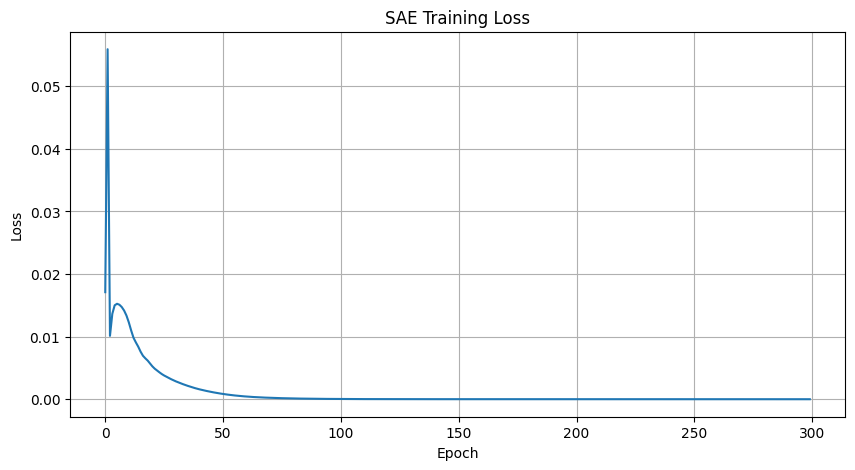

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title("SAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
reconstruction_accuracy = (1 - recon_loss.item()) * 100
print(f"Reconstruction Accuracy: {reconstruction_accuracy:.4f}%")

Reconstruction Accuracy: 100.0000%


In [ ]:
with torch.no_grad():
    recon, _ = model(data)

mse_value = torch.mean((recon - data) ** 2)
print("MSE:", mse_value.item())

MSE: 5.411895998008731e-08


In [ ]:
import shutil

shutil.copy(
    "sae.pt",
    "/content/drive/MyDrive/SAE_Project/sae.pt"
)

print("Saved sae.pt")

Saved sae.pt


Module:5 Features.pt

In [ ]:
!ls

activations.pt	prompts.json  sae_model.py  sample_data
drive		__pycache__   sae.pt


In [ ]:
import torch
from sae_model import SparseAutoencoder

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

data=torch.load('activations.pt').float().to(device)

input_dim=data.shape[1]
hidden_dim=input_dim*4

model=SparseAutoencoder(input_dim,hidden_dim).to(device)
model.load_state_dict(torch.load('sae.pt',map_location=device))
model.eval()

with torch.no_grad():
  _,features=model(data)

features=features.cpu().float()
torch.save(features,'features.pt')
print("Feature shape:",features.shape)
print("Featur dtype:",features.dtype)

feature_strength=features.mean(dim=0)
active=(features>0).float()
activation_rate=active.mean(dim=0)
feature_std=features.std(dim=0)
print('average feature activation rate',activation_rate.mean().item())
print("Mean Feature Strength:",feature_strength.mean().item())
print("Max Feature Strength:",feature_strength.max().item())
print("Min Feature Strength:",feature_strength.min().item())
print("STD feature strength: ",feature_std.mean().item())
top=torch.topk(feature_strength,20)
print("\n Top Features\n ")

for idx,value in zip(top.indices,top.values):
  print(f"feature {idx.item()} | Strength {value.item()}")

print("\n saved features.pt")


Feature shape: torch.Size([2000, 8192])
Featur dtype: torch.float32
average feature activation rate 0.01944085769355297
Mean Feature Strength: 0.005688961129635572
Max Feature Strength: 0.9486469626426697
Min Feature Strength: 0.0
STD feature strength:  0.01446504332125187

 Top Features
 
feature 2176 | Strength 0.9486469626426697
feature 3189 | Strength 0.7511746883392334
feature 3532 | Strength 0.7241817116737366
feature 4314 | Strength 0.6389881372451782
feature 3149 | Strength 0.6268807649612427
feature 3670 | Strength 0.5567668676376343
feature 5829 | Strength 0.5531508326530457
feature 5991 | Strength 0.5173584818840027
feature 5170 | Strength 0.49728336930274963
feature 912 | Strength 0.46490851044654846
feature 5069 | Strength 0.4463544189929962
feature 6095 | Strength 0.43546900153160095
feature 3883 | Strength 0.43507635593414307
feature 324 | Strength 0.4160520136356354
feature 6608 | Strength 0.41232073307037354
feature 6279 | Strength 0.3825373351573944
feature 4714 | Str

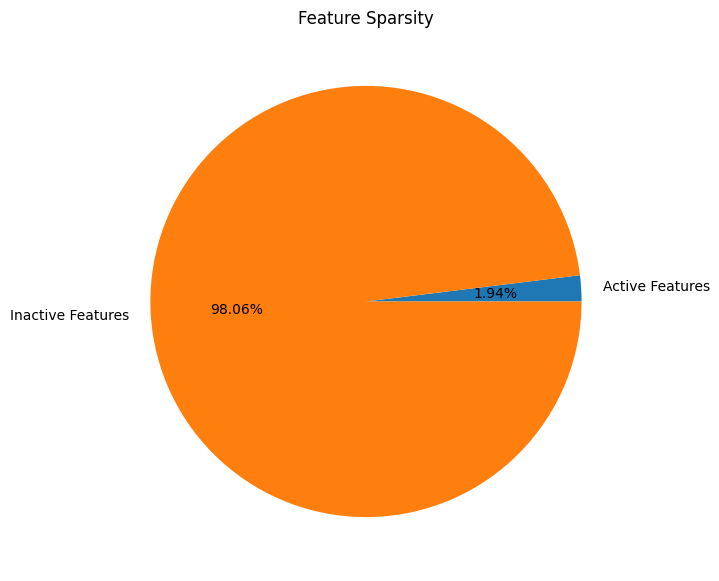

In [ ]:
import matplotlib.pyplot as plt

active_percent = activation_rate.mean().item()*100
inactive_percent = 100-active_percent

plt.figure(figsize=(7,7))
plt.pie([active_percent, inactive_percent],labels=["Active Features","Inactive Features"],autopct="%1.2f%%")
plt.title("Feature Sparsity")
plt.show()

In [ ]:
import shutil

shutil.copy(
    "features.pt",
    "/content/drive/MyDrive/SAE_Project/features.pt"
)

print("Saved features.pt")

Saved features.pt


Module:6 Feature analysis

In [ ]:
import json
import torch

with open('prompts.json','r') as f:
  prompts=json.load(f)

features=torch.load("features.pt")
print("feature shape:",features.shape)

feature_strength=features.mean(dim=0)
active=(features>0).float()
activation_rate=active.mean(dim=0)

feature_score=(feature_strength*activation_rate)
top_features=torch.topk(feature_score,20)
results=[]

coding_keywords = [

    "python",
    "merge",
    "binary",
    "debug",
    "recursion",
    "code",
    "algorithm",
    "linked",
    "list",
    "stack",
    "queue",
    "tree",
    "graph",
    "dfs",
    "bfs",
    "hash",
    "programming"

]

math_keywords = [

    "solve",
    "integrate",
    "derivative",
    "matrix",
    "calculus",
    "probability",
    "statistics",
    "algebra",
    "equation",
    "vector",
    "eigenvalue",
    "trigonometry",
    "determinant"

]

science_keywords = [

    "gravity",
    "dna",
    "physics",
    "photosynthesis",
    "black hole",
    "atom",
    "molecule",
    "electricity",
    "magnetism",
    "cell",
    "ecosystem",
    "evolution",
    "quantum"

]

history_keywords = [

    "napoleon",
    "world war",
    "india",
    "revolution",
    "gandhi",
    "rome",
    "egypt",
    "renaissance",
    "cold war",
    "china"

]

reasoning_keywords = [

    "logic",
    "critical thinking",
    "causality",
    "deduction",
    "induction",
    "reasoning",
    "evidence",
    "argument",
    "decision",
    "bias",
    "hypothesis"

]



feature shape: torch.Size([2000, 8192])


In [ ]:
for feature_id in top_features.indices:
  feature_id =feature_id.item() #item is used to tensor to int
  activations=features[:,feature_id]

  top_samples=torch.topk(activations,20)
  top_prompts=[]

  for idx in top_samples.indices:
    idx=idx.item()
    top_prompts.append(prompts[idx])

  scores = { "Coding": 0,
        "Math": 0,
        "Science": 0,
        "History": 0,
        "Reasoning": 0 }
  for p in top_prompts:
    p=p.lower()

    for w in coding_keywords:
      if w in p:
        scores["Coding"]+=1

    for w in math_keywords:
      if w in p:
        scores["Math"]+=1

    for w in science_keywords:
      if w in p:
        scores["Science"]+=1

    for w in history_keywords:
      if w in p:
        scores["History"]+=1

    for w in reasoning_keywords:
      if w in p:
        scores["Reasoning"]+=1

  best_score=max(scores.values())
  if best_score==0:
    suggested_label='Unknown'
    confidence=0.0
  else:
    best_categories=[category for category,value in scores.items() if value==best_score]
    if len(best_categories)==1:
      suggested_label=best_categories[0]
    else:
      suggested_label=('mixed_'+'_'.join(best_categories))
    confidence=(best_score/sum(scores.values()))
  results.append({
        "feature_id":feature_id,
        "feature_strength":round(feature_strength[feature_id].item(),6),
        "activation_rate":round(activation_rate[feature_id].item(),6),
        "feature_score":round(feature_score[feature_id].item(),6),
        "top_prompts":top_prompts,
        "suggested_label":suggested_label,
        "category_scores":scores,
        "confidence":round(confidence,4)
    })

with open("feature_analysis.json","w") as f:
  json.dump(results,f,indent=4)

print('\n')
print('='*80)
print("Feature Analysis")
print('='*80)

for item in results:
  print('\n')
  print("feature_id:",item['feature_id'])
  print("suggested label:",item['suggested_label'])
  print("confidence:",item['confidence'])
  print("feature_strength:",round(item['feature_strength'],6))
  print("feature score: :",item['feature_score'])
  print("activation score:",item['activation_rate'])
  print("category score: :",item['category_scores'])

  print("\n Top activating prompts:")
  for p in item['top_prompts'][:10]:
    print('-',p)
print("\n saved feature analysis.json")






Feature Analysis


feature_id: 2176
suggested label: Unknown
confidence: 0.0
feature_strength: 0.948647
feature score: : 0.948647
activation score: 1.0
category score: : {'Coding': 0, 'Math': 0, 'Science': 0, 'History': 0, 'Reasoning': 0}

 Top activating prompts:
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change
- Explain climate change


feature_id: 3189
suggested label: History
confidence: 1.0
feature_strength: 0.751175
feature score: : 0.743287
activation score: 0.9895
category score: : {'Coding': 0, 'Math': 0, 'Science': 0, 'History': 20, 'Reasoning': 0}

 Top activating prompts:
- History of China
- History of China
- History of China
- History of China
- History of China
- History of China
- History of China
- History of China
- History of China
- History of China


feature_id: 3532
suggested label: Unkno

In [ ]:
active = (features > 0).float()

activation_rate = active.mean(dim=0)

print(
    "Average Activation Rate:",
    activation_rate.mean().item()
)

Average Activation Rate: 0.01944085769355297


In [ ]:
import shutil

shutil.copy(
    "feature_analysis.json",
    "/content/drive/MyDrive/SAE_Project/feature_analysis.json"
)

print("Saved feature_analysis.json")

Saved feature_analysis.json


In [ ]:
!ls "/content/drive/MyDrive/SAE_Project"

activations.pt		 feature_analysis.json	prompts.json  sae.pt
comparison_results.json  features.pt		sae_model.py  steering.py


Module 7: Steering.py

In [ ]:
%%writefile steering.py
import torch

# 5234 -> Reasoning
# 6901 -> History
# 7307 -> Science
# 3707 -> Coding
# 5290 -> Math

FEATURE_ID=5234
steering_strength=0.10
sae=None
def set_sae(model):
  global sae
  sae=model

def sae_steering_hook(module,inputs,outputs):
  if sae is None:
    return outputs
  if isinstance(outputs,tuple):
    hidden=outputs[0]
  else:
    hidden=outputs

  hidden=hidden.clone()
  device=hidden.device

  # Shape:[batch, seq_len, hidden_size]
  last_token=hidden[:,-1,:]

  with torch.no_grad():
    features=sae.relu(sae.encoder(last_token.float()))
    original_features=features.clone()
    features[:,FEATURE_ID]*=(1+steering_strength)
    delta=sae.decoder(features)-sae.decoder(original_features)
  delta=delta.to(device)
  hidden[:,-1,:]+=delta

  if isinstance(outputs,tuple):
    return(hidden,)+outputs[1:]
  return hidden

Writing steering.py


In [ ]:
import sys
import importlib

if "steering" in sys.modules:
    importlib.reload(sys.modules["steering"])
else:
    import steering

print("steering.py loaded")

steering.py loaded


In [ ]:
import shutil

shutil.copy(
    "steering.py",
    "/content/drive/MyDrive/SAE_Project/steering.py"
)

print("Saved steering.py to Google Drive")

Saved steering.py to Google Drive


In [ ]:
!ls "/content/drive/MyDrive/SAE_Project"

activations.pt		 feature_analysis.json	prompts.json  sae.pt
comparison_results.json  features.pt		sae_model.py  steering.py


Module 8:

In [ ]:
import json
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from sae_model import SparseAutoencoder
import steering
device = ("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME,torch_dtype=(torch.float16 if device == "cuda" else torch.float32))

model.to(device)

model.eval()

print("TinyLlama Loaded")
sae = SparseAutoencoder(input_dim=2048,hidden_dim=8192)
sae.load_state_dict(torch.load("sae.pt",map_location=device))
sae.to(device)
sae.eval()
print("SAE Loaded")
FEATURES = {

    "Reasoning": 5234,

    "History": 6901,

    "Science": 7307,

    "Coding": 3707,

    "Math": 5290

}
PROMPTS = {"Reasoning":
    "Discuss whether artificial intelligence should have legal rights. Provide arguments for and against.",

    "History":
    "Explain the major political, economic, and military reasons behind the fall of the Roman Empire.",

    "Science":
    "Explain in detail how vaccines work and how they help the immune system fight diseases.",

    "Coding":
    "Write a quicksort implementation in Python.",

    "Math":
    "Explain the Pythagorean theorem."}

def generate(prompt):
  inputs = tokenizer(prompt,return_tensors="pt")
  inputs = {k: v.to(device) for k, v in inputs.items()}
  with torch.no_grad():
    output = model.generate(**inputs,max_new_tokens=120,do_sample=True,temperature=0.3,top_p=0.95)
    return tokenizer.decode(output[0],skip_special_tokens=True)

results = []

print("\n")
print("="*80)
print("BASELINE vs STEERED")
print("="*80)

for category in FEATURES:
  prompt = PROMPTS[category]
  feature_id = FEATURES[category]

  baseline = generate(prompt)

  steering.FEATURE_ID = (feature_id)
  steering.set_sae(sae)
  hook = (model.model.layers[12].register_forward_hook(steering.sae_steering_hook))
  steered = generate(prompt)
  hook.remove()
  results.append({
        "category":category,
        "feature_id":feature_id,
        "prompt":prompt,
       "baseline":baseline,
        "steered":steered})
  print("\n")
  print("="*60)
  print("CATEGORY:",category)
  print("FEATURE:",feature_id)
  print("\nPROMPT:\n",prompt)
  print("\nBASELINE:\n")
  print(baseline)
  print("\nSTEERED:\n")
  print(steered)

with open("comparison_results.json","w") as f:
  json.dump(results,f,indent=4)

print("\n")
print("="*80)
print("Saved comparison_results.json")


Using Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama Loaded


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SAE Loaded


BASELINE vs STEERED


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging



CATEGORY: Reasoning
FEATURE: 5234

PROMPT:
 Discuss whether artificial intelligence should have legal rights. Provide arguments for and against.

BASELINE:

Discuss whether artificial intelligence should have legal rights. Provide arguments for and against.

STEERED:

Discuss whether artificial intelligence should have legal rights. Provide arguments for and against.


CATEGORY: History
FEATURE: 6901

PROMPT:
 Explain the major political, economic, and military reasons behind the fall of the Roman Empire.

BASELINE:

Explain the major political, economic, and military reasons behind the fall of the Roman Empire.

STEERED:

Explain the major political, economic, and military reasons behind the fall of the Roman Empire.


CATEGORY: Science
FEATURE: 7307

PROMPT:
 Explain in detail how vaccines work and how they help the immune system fight diseases.

BASELINE:

Explain in detail how vaccines work and how they help the immune system fight diseases.

STEERED:

Explain in detail how vacci

[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




CATEGORY: Coding
FEATURE: 3707

PROMPT:
 Write a quicksort implementation in Python.

BASELINE:

Write a quicksort implementation in Python. The program should prompt the user to enter an array of integers and then sort it using quicksort. The program should also display the sorted array. Make sure to include comments and use appropriate variable names and formatting.

STEERED:

Write a quicksort implementation in Python. Your implementation should use the merge sort algorithm to divide the input array into smaller subarrays, and then recursively apply quicksort to each subarray. Your code should be well-documented and follow PEP 8 style guidelines. Additionally, your implementation should handle edge cases such as empty arrays and arrays with only one element.


CATEGORY: Math
FEATURE: 5290

PROMPT:
 Explain the Pythagorean theorem.

BASELINE:

Explain the Pythagorean theorem.

STEERED:

Explain the Pythagorean theorem.


Saved comparison_results.json


In [ ]:
import time
start = time.time()
baseline = generate(prompt)
end = time.time()
latency = end - start
print("Latency:",latency,"seconds")

start = time.time()
steered = generate(prompt)
end = time.time()

start = time.time()
output = generate(prompt)
end = time.time()
steered_latency=end-start
print("steered latency",steered_latency,"seconds")
tokens = len(output.split())
throughput = tokens/(end-start)
print("Tokens Per Second:",throughput)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Latency: 0.1161808967590332 seconds
steered latency 0.15242409706115723 seconds
Tokens Per Second: 26.242569758475113


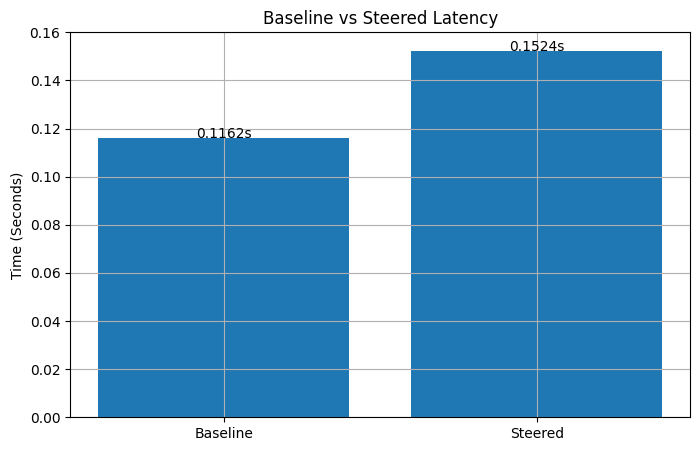

In [ ]:
import matplotlib.pyplot as plt

labels = ["Baseline","Steered"]
values = [latency,steered_latency]
plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Baseline vs Steered Latency")
plt.ylabel("Time (Seconds)")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}s", ha='center')

plt.grid(True)
plt.show()

In [ ]:
import shutil

shutil.copy(
    "comparison_results.json",
    "/content/drive/MyDrive/SAE_Project/comparison_results.json"
)

print("Saved comparison_results.json")

Saved comparison_results.json


In [ ]:
!ls "/content/drive/MyDrive/SAE_Project"

activations.pt		 feature_analysis.json	prompts.json  sae.pt
comparison_results.json  features.pt		sae_model.py  steering.py


In [ ]:
import shutil

files = [
    "prompts.json",
    "activations.pt",
    "sae.pt",
    "features.pt",
    "feature_analysis.json",
    "comparison_results.json",
    "sae_model.py",
    "steering.py"
]

for file in files:
    shutil.copy(
        file,
        f"/content/drive/MyDrive/SAE_Project/{file}"
    )
    print(f"Saved {file}")

print("\nAll project files saved successfully!")

Saved prompts.json
Saved activations.pt
Saved sae.pt
Saved features.pt
Saved feature_analysis.json
Saved comparison_results.json
Saved sae_model.py
Saved steering.py

All project files saved successfully!


In [ ]:
!zip -r SAE_Project.zip \
prompts.json \
activations.pt \
sae.pt \
features.pt \
feature_analysis.json \
comparison_results.json \
sae_model.py \
steering.py

  adding: prompts.json (deflated 90%)
  adding: activations.pt (deflated 43%)
  adding: sae.pt (deflated 8%)
  adding: features.pt (deflated 97%)
  adding: feature_analysis.json (deflated 94%)
  adding: comparison_results.json (deflated 71%)
  adding: sae_model.py (deflated 59%)
  adding: steering.py (deflated 49%)


In [ ]:
from google.colab import files

files.download("SAE_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls

activations.pt		 feature_analysis.json	__pycache__	 sae.pt
comparison_results.json  features.pt		sae_model.py	 sample_data
drive			 prompts.json		SAE_Project.zip  steering.py
